# Notebook 05b — TwitterRoBERTa Fine-Tuning


## Model Setup and Environment Configuration

This section initialises the environment for training the transformer-based model. It includes loading required libraries, importing configuration parameters, and preparing paths for saving model outputs and visualisations.

The setup also determines the available compute device, prioritising GPU acceleration where possible, to ensure efficient model training.

In [1]:
# Path setup for config import
import sys, os, pickle, time, copy
sys.path.insert(0, os.path.abspath('..'))

# Core libraries
import pandas as pd, numpy as np, matplotlib.pyplot as plt

# PyTorch modules
import torch, torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# Transformer utilities
from transformers import (
    AutoTokenizer, AutoModel,
    DataCollatorWithPadding,
    get_linear_schedule_with_warmup
)

# Evaluation metrics
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    ConfusionMatrixDisplay
)

# Suppress warnings and transformer logs
import warnings; warnings.filterwarnings('ignore')
from transformers import logging as hf_logging; hf_logging.set_verbosity_error()

# Import configuration
import config
from config import (
    LABELLED_DATASET,
    PLOTS_DIR,
    TWITTERROBERTA_DIR,
    TWITTERROBERTA_MODEL_ID,
    TWITTERROBERTA_PREDS_PKL,
    TWITTERROBERTA_RESULTS_CSV,
    NUM_LABELS,
    MAX_LENGTH,
    BATCH_SIZE,
    NUM_EPOCHS,
    LEARNING_RATE,
    WEIGHT_DECAY,
    WARMUP_RATIO,
    EARLY_STOPPING_PATIENCE,
)

# Create output directories
os.makedirs(PLOTS_DIR / 'twitterroberta_model', exist_ok=True)
os.makedirs(TWITTERROBERTA_DIR, exist_ok=True)

# Display model being used
print(f'Model: {TWITTERROBERTA_MODEL_ID}')

# Select available compute device
if torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
elif torch.cuda.is_available():
    DEVICE = torch.device('cuda')
else:
    DEVICE = torch.device('cpu')

print(f'Device: {DEVICE}')

/Users/latikasisodiya/Documents/PROJECTS/depression_detection_nlp_project/venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Model: cardiffnlp/twitter-roberta-base-sentiment-latest
Device: mps


## Dataset Loading and Splitting

This step loads the processed labelled dataset and separates it into training, validation, and test subsets based on the predefined split column. 

This ensures a clear distinction between data used for model training, hyperparameter tuning, and final evaluation, which is essential for obtaining unbiased performance estimates.

In [2]:
# Load labelled dataset
df = pd.read_csv(LABELLED_DATASET)

# Create train, validation, and test splits
train = df[df['split'] == 'train'].reset_index(drop=True)
val   = df[df['split'] == 'val'].reset_index(drop=True)
test  = df[df['split'] == 'test'].reset_index(drop=True)

# Print dataset sizes
print(f'Train: {len(train):,}  Val: {len(val):,}  Test: {len(test):,}')

Train: 3,996  Val: 3,996  Test: 1,998


## Tokenisation and Input Preparation

This step initialises the tokenizer corresponding to the selected transformer model and prepares a data collator for dynamic padding during batching.

A sample sentence is tokenised to inspect how the model processes input text, ensuring that special tokens and domain-specific patterns are handled correctly before training.

In [3]:
# Load tokenizer
tokenizer = AutoTokenizer.from_pretrained(TWITTERROBERTA_MODEL_ID)

# Data collator for dynamic padding
collator = DataCollatorWithPadding(tokenizer=tokenizer, return_tensors='pt')

# Print vocabulary size
print(f'Vocab size: {tokenizer.vocab_size:,}')

# Sample tokenisation
sample = 'i do not want to feel happy_NEG anymore'
tokens = tokenizer(sample, truncation=True, max_length=32)['input_ids']
print('Tokens:', tokenizer.convert_ids_to_tokens(tokens))

Vocab size: 50,265
Tokens: ['<s>', 'i', 'Ġdo', 'Ġnot', 'Ġwant', 'Ġto', 'Ġfeel', 'Ġhappy', '_', 'N', 'EG', 'Ġanymore', '</s>']


## Custom Dataset for Model Input

This section defines a custom PyTorch dataset to structure the input data for transformer-based training. It handles tokenised text, attention masks, and corresponding labels required by the model.

An optional intensifier feature is also incorporated when available, allowing the model to leverage additional signal beyond textual content during training.

In [4]:
# Custom dataset for transformer input
class SuicideDataset(Dataset):
    def __init__(self, df, tokenizer, text_col='text_clean',
                 label_col='label_id', max_length=128, use_intensifier=False):
        
        # Extract and clean text data
        texts = df[text_col].fillna('').tolist()
        
        # Tokenise text
        enc = tokenizer(
            texts,
            truncation=True,
            max_length=max_length,
            padding=False,
            return_tensors=None
        )
        
        # Store tokenised inputs
        self.input_ids      = enc['input_ids']
        self.attention_mask = enc['attention_mask']
        
        # Store labels
        self.labels = df[label_col].tolist()
        
        # Optional intensifier feature
        self.intensifier = (
            df['intensifier_score'].fillna(0).tolist()
            if use_intensifier and 'intensifier_score' in df.columns else None
        )

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        # Prepare single sample
        item = {
            'input_ids': self.input_ids[idx],
            'attention_mask': self.attention_mask[idx],
            'labels': self.labels[idx]
        }
        
        # Add intensifier if available
        if self.intensifier is not None:
            item['intensifier'] = self.intensifier[idx]
        
        return item

## Model Architecture: TwitterRoBERTa Classifier

This section defines the neural architecture used for classification. The model is based on a pre-trained TwitterRoBERTa encoder, followed by a fully connected classification head.

The architecture mirrors the baseline RoBERTa setup to ensure a fair comparison, with a slightly higher dropout applied to reduce overfitting. An optional linguistic feature can also be incorporated to enrich the representation before classification.

In [5]:
# TwitterRoBERTa-based classifier
class TwitterRoBERTaClassifier(nn.Module):
    """
    TwitterRoBERTa fine-tuned classifier.
    Architecture is identical to RoBERTaClassifier for fair comparison.
    Higher dropout used to reduce overfitting.
    """
    def __init__(self, model_id, num_labels=2, use_linguistic=False, dropout=0.2):
        super().__init__()
        
        # Load pretrained encoder
        self.encoder = AutoModel.from_pretrained(model_id)
        hidden = self.encoder.config.hidden_size
        
        # Optional linguistic feature flag
        self.use_linguistic = use_linguistic
        
        # Input dimension adjustment
        in_dim = hidden + 1 if use_linguistic else hidden
        
        # Classification head
        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(in_dim, 256),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(256, num_labels),
        )

    def forward(self, input_ids, attention_mask, intensifier=None):
        # Encoder forward pass
        out = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        
        # CLS token representation
        pooled = out.last_hidden_state[:, 0, :]
        
        # Concatenate linguistic feature if enabled
        if self.use_linguistic and intensifier is not None:
            pooled = torch.cat([pooled, intensifier.unsqueeze(1)], dim=1)
        
        # Classification output
        return self.classifier(pooled)

## Training and Evaluation Utilities
This section defines the core training and evaluation routines used during model optimisation. The training function performs forward and backward passes, updates model parameters, and tracks loss and accuracy.

The evaluation function runs the model in inference mode to compute performance metrics on validation or test data. It aggregates predictions, probabilities, and labels to calculate metrics such as F1 score and ROC-AUC, providing a comprehensive view of model performance.

In [6]:
# Training loop for one epoch
def train_epoch(model, loader, optimizer, scheduler, criterion, device):
    model.train()
    total_loss, correct, total = 0, 0, 0
    
    for batch in loader:
        # Move inputs to device
        ids   = batch['input_ids'].to(device)
        masks = batch['attention_mask'].to(device)
        labs  = batch['labels'].to(device)
        
        # Optional intensifier feature
        inten = batch.get('intensifier')
        if inten is not None:
            inten = inten.to(device)
        
        # Forward + backward pass
        optimizer.zero_grad()
        logits = model(ids, masks, inten)
        loss   = criterion(logits, labs)
        loss.backward()
        
        # Gradient clipping
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        
        # Optimiser step
        optimizer.step()
        scheduler.step()
        
        # Track metrics
        total_loss += loss.item() * len(labs)
        correct    += (logits.argmax(1) == labs).sum().item()
        total      += len(labs)
    
    return total_loss / total, correct / total


# Evaluation loop
@torch.no_grad()
def evaluate_epoch(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    P, L, Pr = [], [], []
    
    for batch in loader:
        # Move inputs to device
        ids   = batch['input_ids'].to(device)
        masks = batch['attention_mask'].to(device)
        labs  = batch['labels'].to(device)
        
        # Optional intensifier feature
        inten = batch.get('intensifier')
        if inten is not None:
            inten = inten.to(device)
        
        # Forward pass
        logits = model(ids, masks, inten)
        loss   = criterion(logits, labs)
        
        # Probabilities for positive class
        probs = torch.softmax(logits, 1)[:, 1]
        
        # Accumulate results
        total_loss += loss.item() * len(labs)
        P.append(logits.argmax(1).cpu())
        L.append(labs.cpu())
        Pr.append(probs.cpu())
    
    # Concatenate outputs
    P  = torch.cat(P).numpy()
    L  = torch.cat(L).numpy()
    Pr = torch.cat(Pr).numpy()
    
    return {
        'loss': total_loss / len(loader.dataset),
        'accuracy': accuracy_score(L, P),
        'f1': f1_score(L, P, pos_label=1),
        'recall': recall_score(L, P, pos_label=1),
        'precision': precision_score(L, P, pos_label=1),
        'roc_auc': roc_auc_score(L, Pr),
        'preds': P.tolist(),
        'labels': L.tolist(),
        'probs': Pr.tolist()
    }

## Experiment Runner and Training Pipeline

This section defines a unified function to train and evaluate the model under different experimental configurations. It handles dataset preparation, model initialisation, optimisation setup, and training with early stopping.

The function ensures consistency across experiments by reusing the same encoder weights and tracking validation performance to retain the best model checkpoint. This enables fair comparison between different input settings and feature combinations.

In [7]:
# Experiment runner for training and validation
_base_state = None

def run_experiment(text_col, use_intensifier, experiment_name):
    global _base_state
    
    print(f"\n{'='*55}\n{experiment_name}\n{'='*55}")
    
    # Dataset preparation
    t0 = time.time()
    train_ds = SuicideDataset(
        train, tokenizer,
        text_col=text_col,
        max_length=MAX_LENGTH,
        use_intensifier=use_intensifier
    )
    val_ds = SuicideDataset(
        val, tokenizer,
        text_col=text_col,
        max_length=MAX_LENGTH,
        use_intensifier=use_intensifier
    )
    print(f'  Tokenised in {time.time()-t0:.1f}s')
    
    # Data loaders
    kw = dict(
        num_workers=0,
        pin_memory=(DEVICE.type == 'cuda'),
        collate_fn=collator
    )
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, **kw)
    val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE * 2, shuffle=False, **kw)
    
    # Model initialisation
    model = TwitterRoBERTaClassifier(
        TWITTERROBERTA_MODEL_ID,
        num_labels=NUM_LABELS,
        use_linguistic=use_intensifier
    ).to(DEVICE)
    
    # Reuse base encoder weights for fair comparison
    if _base_state is None:
        _base_state = copy.deepcopy(model.encoder.state_dict())
    else:
        model.encoder.load_state_dict(_base_state)
    
    # Optimiser and scheduler
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY
    )
    
    total_steps = len(train_loader) * NUM_EPOCHS
    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        int(total_steps * WARMUP_RATIO),
        total_steps
    )
    
    # Loss function
    criterion = nn.CrossEntropyLoss()
    
    # Checkpoint path
    ckpt = os.path.join(
        TWITTERROBERTA_DIR,
        f'best_{experiment_name.replace(" ","_")}.pt'
    )
    
    # Training loop with early stopping
    history, best_f1, patience = [], 0, 0
    
    for epoch in range(1, NUM_EPOCHS + 1):
        t0 = time.time()
        
        tl, ta = train_epoch(model, train_loader, optimizer, scheduler, criterion, DEVICE)
        vm = evaluate_epoch(model, val_loader, criterion, DEVICE)
        
        history.append({
            'epoch': epoch,
            'train_loss': tl,
            'val_f1': vm['f1'],
            'val_recall': vm['recall']
        })
        
        print(
            f'  Epoch {epoch}/{NUM_EPOCHS}  '
            f'loss={tl:.4f}  val_f1={vm["f1"]:.4f}  '
            f'recall={vm["recall"]:.4f}  ({time.time()-t0:.0f}s)'
        )
        
        # Save best model
        if vm['f1'] > best_f1:
            best_f1 = vm['f1']
            torch.save(model.state_dict(), ckpt)
            patience = 0
        else:
            patience += 1
            if patience >= EARLY_STOPPING_PATIENCE:
                print('  Early stopping.')
                break
    
    # Load best checkpoint
    model.load_state_dict(torch.load(ckpt, map_location=DEVICE, weights_only=True))
    
    return (
        model,
        pd.DataFrame(history),
        evaluate_epoch(model, val_loader, criterion, DEVICE),
        experiment_name
    )

## Baseline Experiment Execution

This step runs the baseline experiment using the cleaned text input without any additional linguistic features. It serves as a reference point for evaluating the impact of feature enhancements in subsequent experiments.

The model is trained and validated using the standard pipeline, and its performance metrics are stored for comparison.

In [8]:
# Run baseline experiment (text only)
model_base, hist_base, val_base, name_base = run_experiment(
    'text_clean',
    False,
    'TwitterRoBERTa Baseline'
)


TwitterRoBERTa Baseline
  Tokenised in 0.5s


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 38159.67it/s]


  Epoch 1/3  loss=0.2657  val_f1=0.9733  recall=0.9661  (267s)
  Epoch 2/3  loss=0.0804  val_f1=0.9763  recall=0.9682  (315s)
  Epoch 3/3  loss=0.0227  val_f1=0.9805  recall=0.9788  (346s)


## Negation-Aware Experiment

This experiment evaluates the model using negation-tagged text to better capture sentiment shifts caused by negation. By explicitly marking negated expressions, the model can distinguish between positive and negated-positive contexts.

All other settings remain unchanged from the baseline, ensuring a fair comparison of the impact of negation handling.

In [9]:
# Run experiment with negation-tagged input
model_neg, hist_neg, val_neg, name_neg = run_experiment(
    'text_neg_tagged',
    False,
    'TwitterRoBERTa + Negation'
)


TwitterRoBERTa + Negation
  Tokenised in 0.6s


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 54778.93it/s]


  Epoch 1/3  loss=0.2734  val_f1=0.9721  recall=0.9853  (368s)
  Epoch 2/3  loss=0.0809  val_f1=0.9760  recall=0.9672  (355s)
  Epoch 3/3  loss=0.0299  val_f1=0.9780  recall=0.9793  (360s)


## Full Feature Experiment: Negation and Intensifier

This experiment extends the negation-aware setup by incorporating an additional linguistic feature representing intensifier strength. This allows the model to account for variations in emotional intensity alongside polarity shifts.

By combining negation tagging with intensifier information, the model is expected to capture more nuanced patterns in the text, potentially improving classification performance.

In [10]:
# Run experiment with negation + intensifier features
model_full, hist_full, val_full, name_full = run_experiment(
    'text_neg_tagged',
    True,
    'TwitterRoBERTa + Negation + Intensifier'
)


TwitterRoBERTa + Negation + Intensifier
  Tokenised in 0.8s


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 60800.30it/s]


  Epoch 1/3  loss=0.3026  val_f1=0.9732  recall=0.9616  (356s)
  Epoch 2/3  loss=0.0825  val_f1=0.9796  recall=0.9803  (367s)
  Epoch 3/3  loss=0.0340  val_f1=0.9780  recall=0.9778  (360s)


## Ablation Results and Performance Comparison

This section summarises the performance of all experimental configurations and visualises their training behaviour. The results are aggregated into a comparison table to highlight differences across accuracy, precision, recall, F1 score, and ROC-AUC.

Training curves illustrate convergence patterns, while confusion matrices provide insight into class-wise prediction performance, enabling a deeper understanding of model behaviour across experiments.

                             Experiment  Accuracy  Precision  Recall     F1  ROC-AUC
                TwitterRoBERTa Baseline    0.9807     0.9823  0.9788 0.9805   0.9979
              TwitterRoBERTa + Negation    0.9782     0.9768  0.9793 0.9780   0.9978
TwitterRoBERTa + Negation + Intensifier    0.9797     0.9788  0.9803 0.9796   0.9978


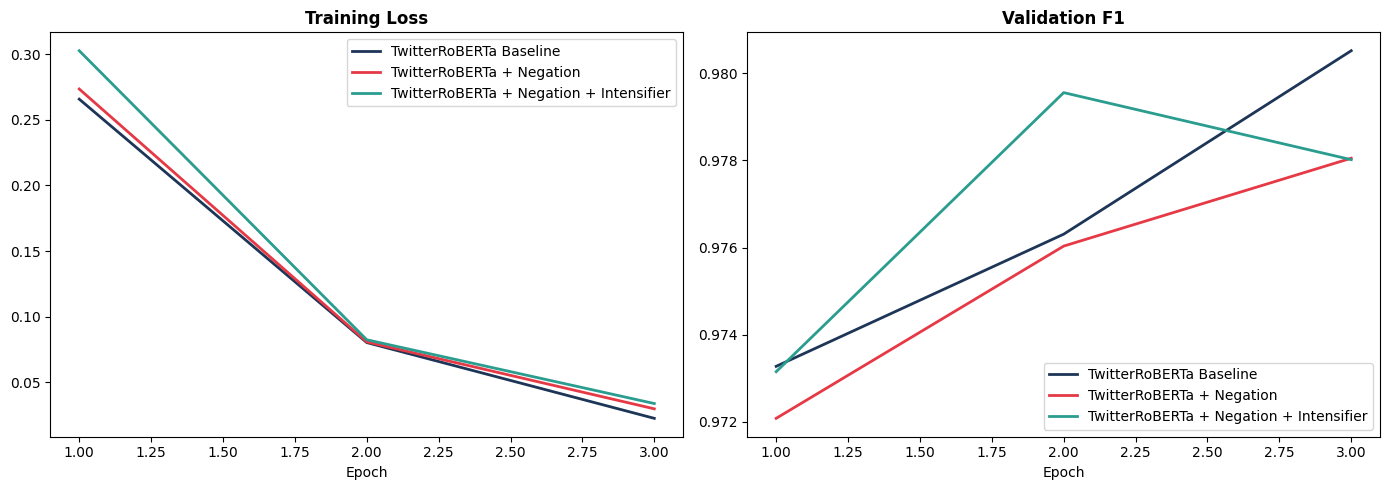

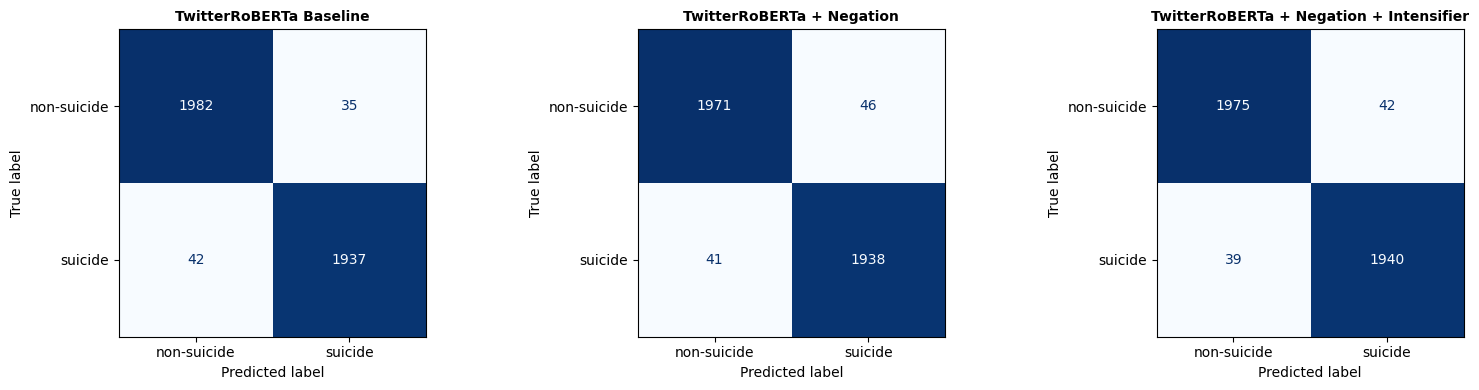

In [11]:
# Compile ablation results
rows = []
for name, m in [(name_base, val_base), (name_neg, val_neg), (name_full, val_full)]:
    rows.append({
        'Experiment': name,
        'Accuracy': round(m['accuracy'], 4),
        'Precision': round(m['precision'], 4),
        'Recall': round(m['recall'], 4),
        'F1': round(m['f1'], 4),
        'ROC-AUC': round(m['roc_auc'], 4)
    })

ablation_df = pd.DataFrame(rows)
print(ablation_df.to_string(index=False))


# Plot training curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ['#1D3557', '#E63946', '#2A9D8F']

for hist, name, c in zip(
    [hist_base, hist_neg, hist_full],
    [name_base, name_neg, name_full],
    colors
):
    axes[0].plot(hist['epoch'], hist['train_loss'], label=name, color=c, linewidth=2)
    axes[1].plot(hist['epoch'], hist['val_f1'], label=name, color=c, linewidth=2)

for ax, t in zip(axes, ['Training Loss', 'Validation F1']):
    ax.set_title(t, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.legend()

plt.tight_layout()
plt.savefig(PLOTS_DIR / 'twitterroberta_model' / 'training_curves.png', bbox_inches='tight')
plt.show()


# Plot confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, name, m in zip(
    axes,
    [name_base, name_neg, name_full],
    [val_base, val_neg, val_full]
):
    ConfusionMatrixDisplay(
        confusion_matrix(m['labels'], m['preds']),
        display_labels=['non-suicide', 'suicide']
    ).plot(ax=ax, colorbar=False, cmap='Blues')
    
    ax.set_title(name, fontweight='bold', fontsize=10)

plt.tight_layout()
plt.savefig(PLOTS_DIR / 'twitterroberta_model' / 'ablation_cm.png', bbox_inches='tight')
plt.show()

## Best Model Selection and Test Evaluation

This step identifies the best-performing configuration based on validation F1 score and evaluates it on the unseen test set. The selected model is then used to generate final predictions and performance metrics.

The results are saved for further analysis, ensuring reproducibility and enabling downstream reporting or comparison with other models.

In [12]:
# Select best experiment based on validation F1
best_idx = ablation_df['F1'].idxmax()
best_condition = ablation_df.loc[best_idx, 'Experiment']

print(f'Best condition: {best_condition}')

# Map experiment to corresponding model and configuration
best_map = {
    name_base: (model_base, 'text_clean', False),
    name_neg:  (model_neg,  'text_neg_tagged', False),
    name_full: (model_full, 'text_neg_tagged', True)
}

bm, bc, bi = best_map[best_condition]

# Prepare test dataset
test_ds = SuicideDataset(
    test,
    tokenizer,
    text_col=bc,
    max_length=MAX_LENGTH,
    use_intensifier=bi
)

test_loader = DataLoader(
    test_ds,
    batch_size=BATCH_SIZE * 2,
    collate_fn=collator
)

# Evaluate on test set
test_metrics = evaluate_epoch(
    bm,
    test_loader,
    nn.CrossEntropyLoss(),
    DEVICE
)

# Print classification report
print(classification_report(
    test_metrics['labels'],
    test_metrics['preds'],
    target_names=['non-suicide', 'suicide']
))

# Save predictions and results
with open(TWITTERROBERTA_PREDS_PKL, 'wb') as f:
    pickle.dump({
        'ablation': ablation_df,
        'test_preds': test_metrics['preds'],
        'test_labels': test_metrics['labels'],
        'test_probs': test_metrics['probs'],
        'best_condition': best_condition
    }, f)

ablation_df.to_csv(TWITTERROBERTA_RESULTS_CSV, index=False)

Best condition: TwitterRoBERTa Baseline
              precision    recall  f1-score   support

 non-suicide       0.99      0.98      0.98      1008
     suicide       0.98      0.99      0.98       990

    accuracy                           0.98      1998
   macro avg       0.98      0.98      0.98      1998
weighted avg       0.98      0.98      0.98      1998

